In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from multiprocessing import Pool,cpu_count
import time
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
sns.set_theme()

AIR DATA

Helper functions

In [2]:
BP_O3_1h=[
    (0,160,0,50),
    (160,200,50,100),
    (200,300,100,150),
    (300,400,150,200),
    (400,800,200,300),
    (800,1000,300,400),
    (1000,1200,400,500)
]
BP_O3_8h=[
    (0,100,0,50),
    (100,120,50,100),
    (120,170,100,150),
    (170,210,150,200),
    (210,400,200,300),
]
BP_CO=[
    (0,10000,0,50),
    (10000,30000,50,100),
    (30000,45000,100,150),
    (45000,60000,150,200),
    (60000,90000,200,300),
    (90000,120000,300,400),
    (120000,150000,400,500),
]
BP_SO2=[
    (0,125,0,50),
    (125,350,50,100),
    (350,550,100,150),
    (550,800,150,200),
    (800,1600,200,300),
    (1600,2100,300,400),
    (2100,2630,400,500)
]
BP_NO2 = [
    (0,    100,   0,  50),
    (100,  200,  50, 100),
    (200,  700, 100, 150),
    (700, 1200, 150, 200),
    (1200, 2350, 200, 300),
    (2350, 3100, 300, 400),
    (3100, 3850, 400, 500),
]
BP_PM10 = [
    (0,    50,   0,  50),
    (50,  150,  50, 100),
    (150, 250, 100, 150),
    (250, 350, 150, 200),
    (350, 420, 200, 300),
    (420, 500, 300, 400),
    (500, 600, 400, 500),
]
BP_PM25 = [
    (0,   25,   0,  50),
    (25,  50,  50, 100),
    (50,  80, 100, 150),
    (80, 150, 150, 200),
    (150, 250, 200, 300),
    (250, 350, 300, 400),
    (350, 500, 400, 500),
]
BP_dict={
    'ozone':BP_O3_1h,
    'ozone(8h)':BP_O3_8h,
    'carbon_monoxide':BP_CO,
    'sulphur_dioxide':BP_SO2,
    'nitrogen_dioxide':BP_NO2,
    'pm10':BP_PM10,
    'pm2_5':BP_PM25
}
#apply aqi for all records not single records
def build_aqi_conditions_and_choices(values,bp_list):
    conditions=[]
    choices=[]
    for(bpi,bpi_1,i,i_1) in bp_list:
        conditions.append((values>=bpi) &(values<=bpi_1))
        choices.append(np.round(((i_1-i)/(bpi_1-bpi))*(values-bpi)+i))
    return conditions,choices
def calculate_aqi_value(series,_type):
    values=series.to_numpy()
    bp_list=BP_dict[_type]
    conditions,choices=build_aqi_conditions_and_choices(values,bp_list)
    return np.select(conditions,choices,default=500)
def progress_bar(progress,total,display_length=60):
    left_ratio=display_length*progress//total
    right_ratio=display_length-left_ratio
    print('['+ '='*left_ratio + '>' + '.'*right_ratio + f'] {progress} / {total}', end='\r') 

In [3]:
def clip(number,lower):
    if number<=lower:
        return lower
    return number
def cal_weight(window):
    c_max=window.max()
    c_min=window.min()
    w=c_min/c_max
    w=clip(number=w,lower=0.5)
    if w==1/2:
        return sum([window.iloc[i]*w**(i+1) for i in range(len(window))])
    return sum([window.iloc[i-1]*w**(i-1) for i in range(1,len(window)+1)])/sum([w**(i-1) for i in range(1,len(window)+1)])
def calculate_nowcast(data):
    rolling=data.rolling(window=12,min_periods=2)
    
    return rolling.apply(cal_weight,raw=False)

In [4]:
def calculate_nowcast_vectorized(series):
    values=series.to_numpy(dtype=float)
    n=len(values)
    result=np.full(n,np.nan)
    #using sliding window algorithm
    for start in range(1,n):
        end=start+1
        # if end position is lower than 12 then set the window start is 0
        window_start=max(0,end-12)
        # c1 -> c12 window: if have less than 12 state, start from 0 to i
        window=values[window_start:end]
        valid=window[~np.isnan(window)]
        if len(valid)<2:
            #if only c1 set c1 is the nowcast
            if len(valid)==1:
                result[start]=valid[0]
            continue
        c_max=valid.max()
        c_min=valid.min()
        # prevent division by zero
        if c_max==0:
            result[start]=0
            continue
        w=max(c_min/c_max,0.5)
        L=len(valid)
        exponents=np.arange(L)
        if w==0.5:
            weights=w**(exponents+1)
            result[start]=np.dot(valid,weights)
        else:
            weights=w**exponents
            result[start]=np.dot(valid,weights)/weights.sum()
    return pd.Series(result,index=series.index)
    

In [5]:
def calculate_aqi_8h_vectorized(series):
    values=series.to_numpy(dtype=float)
    n=len(values)
    result=np.full(n,np.nan)
    for start in range(1,n):
        end=start+1
        window_start=max(0,end-8)
        window=values[window_start:end]
        window=window[~np.isnan(window)]
        result[start]=round(sum(window)/8)
    return pd.Series(result,index=series.index)

In [6]:
#try multiprocessing
def _process_group(groups):
    district,group,aqi_columns=groups
    for column in aqi_columns:
        aqi_index=column.split()[0]
        if column in ['pm10 (μg/m³)', 'pm2_5 (μg/m³)']:
            group[f'nowcast_{aqi_index}']=calculate_nowcast_vectorized(group[column])
            source=group[f'nowcast_{aqi_index}']
        else:
            source=group[column]
        group[f'aqi_{aqi_index}']=calculate_aqi_value(source,aqi_index)     
    return group

In [7]:
def _process_group_day(groups):
    district,group,aqi_columns=groups
    pm25_24h=group['pm2_5 (μg/m³)'].resample('D').mean()
    pm10_24h=group['pm10 (μg/m³)'].resample('D').mean()
    so2_1h_max=group['sulphur_dioxide (μg/m³)'].resample('D').max()
    no2_1h_max=group['nitrogen_dioxide (μg/m³)'].resample('D').max()
    co_1h_max=group['carbon_monoxide (μg/m³)'].resample('D').max()
    o3_1h_max=group['ozone (μg/m³)'].resample('D').max()
    group['aqi_o3_8h']=calculate_aqi_8h_vectorized(group['ozone (μg/m³)'])
    o3_8h_max=group['aqi_o3_8h'].resample('D').max()
    aqi_o3_1h = calculate_aqi_value(o3_1h_max, 'ozone')
    aqi_o3_8h = np.where(
            o3_8h_max > 400,
            np.nan,   
            calculate_aqi_value(o3_8h_max, 'ozone(8h)')
        )
    aqi_o3=np.fmax(aqi_o3_1h,aqi_o3_8h)
    days=pm25_24h.index
    daily = pd.DataFrame({
            'district':             district,
            'city':                 group['city'].resample('D'),
            'aqi_pm2_5':            calculate_aqi_value(pm25_24h,  'pm2_5'),
            'aqi_pm10':             calculate_aqi_value(pm10_24h,  'pm10'),
            'aqi_sulphur_dioxide':  calculate_aqi_value(so2_1h_max,'sulphur_dioxide'),
            'aqi_nitrogen_dioxide': calculate_aqi_value(no2_1h_max,'nitrogen_dioxide'),
            'aqi_carbon_monoxide':  calculate_aqi_value(co_1h_max, 'carbon_monoxide'),
            'aqi_ozone':            aqi_o3,
        }, index=days)
    pm_available = ~(daily['aqi_pm2_5'].isna() & daily['aqi_pm10'].isna())
    daily['aqi_daily'] = np.where(
        pm_available,
        daily[['aqi_pm2_5','aqi_pm10','aqi_sulphur_dioxide',
            'aqi_nitrogen_dioxide','aqi_carbon_monoxide','aqi_ozone']].max(axis=1).round().astype('Int64'),
            pd.NA
        )
    return daily

In [8]:
class AirData:
    def __init__(self,data_path):
        self.data_path=data_path
        self.northVN_dataAIR=pd.read_csv(os.path.join(self.data_path,'northVN_dataAIR.csv'), parse_dates=['time'], index_col='time')
        self.centralVN_dataAIR=pd.read_csv(os.path.join(self.data_path,'centralVN_dataAIR.csv'), parse_dates=['time'], index_col='time')
        self.southVN_dataAIR=pd.read_csv(os.path.join(self.data_path,'southVN_dataAIR.csv'), parse_dates=['time'], index_col='time')
        self.northVN_dataAIR=self.northVN_dataAIR.drop(['carbon_dioxide (ppm)'],axis=1)
        self.centralVN_dataAIR=self.centralVN_dataAIR.drop(['carbon_dioxide (ppm)'],axis=1)
        self.southVN_dataAIR=self.southVN_dataAIR.drop(['carbon_dioxide (ppm)'],axis=1)
        self.numerical_columns=['pm10 (μg/m³)', 'pm2_5 (μg/m³)','carbon_monoxide (μg/m³)',
                                'nitrogen_dioxide (μg/m³)', 'sulphur_dioxide (μg/m³)', 'ozone (μg/m³)',
                                'aerosol_optical_depth ()', 'dust (μg/m³)', 'uv_index ()',
                                'uv_index_clear_sky ()']
        self.aqi_columns=['pm10 (μg/m³)', 'pm2_5 (μg/m³)','carbon_monoxide (μg/m³)','nitrogen_dioxide (μg/m³)', 'sulphur_dioxide (μg/m³)', 'ozone (μg/m³)']
        self.names=["Miền Bắc","Miền Nam",'Miền Trung']
        self.dfs=[self.northVN_dataAIR,self.southVN_dataAIR,self.centralVN_dataAIR]
        print('load air data sucessfully!')
    def location_analysis(self):
        #Tong so dia diem mien bac
        n_locations=len(self.northVN_dataAIR['district'].unique())
        #Tong so dia diem mien Nam
        s_locations=len(self.southVN_dataAIR['district'].unique())
        #Tong so dia diem mien Trung
        c_locations=len(self.centralVN_dataAIR['district'].unique())
        #Tong so dia diem tren Viet Nam
        total_locations=n_locations+s_locations+c_locations
        print("Tổng số địa điểm miền Bắc: {} địa điểm.".format(n_locations))
        print("Tổng số địa điểm miền Nam: {} địa điểm.".format(s_locations))
        print("Tổng số địa điểm miền Trung: {} địa điểm.".format(c_locations))
        print("Tổng số địa điểm trên Việt Nam: {} địa điểm.".format(total_locations))
        fig,ax=plt.subplots()
        ax.bar(["Miền Bắc","Miền Trung","Miền Nam","Tổng"],[n_locations,c_locations,s_locations,total_locations])
        ax.set_title('Tổng số địa điểm')
    def check_nan(self):
        for name,df in zip(self.names,self.dfs):
            dt={}
            print(f"Số dữ liệu NaN {name}")
            for column in df.columns:
                total_nan=df[column].isna().sum()
                dt[column]=int(total_nan)
                print('Chỉ số: {} Số giá trị thiếu: {}/{} Tỉ lệ: {:.2f} % '.format(column,total_nan,df.shape[0],total_nan*100/df.shape[0]))
            fix,ax=plt.subplots()
            dt={k: v for k, v in sorted(dt.items(), key=lambda item: item[1],reverse=True)}
            ax.bar(list(dt.keys())[:3],list(dt.values())[:3])
            ax.set_title("Top 3 chỉ số có giá trị NaN nhiều nhất")
            print('-'*50)
    def get_statistic_features(self):
        for name,df in zip(self.names,self.dfs):
            print("Đặc trưng thống kê {}:".format(name))
            for column in self.numerical_columns:
                mean=df[column].mean()
                std=np.std(df[column])
                print("Giá trị: {}, Trung bình: {:.2f}, Độ lệch chuẩn: {:.2f}".format(column,mean,std))
            print('-'*50)
    def handle_missing_value(self,drop=False):
        for name,df in zip(self.names,self.dfs):
            print("Hanle missing value in {}".format(name))
            for column in self.numerical_columns:
                if drop:
                    df.drop([column])
                else:
                    mean=df[column].mean()
                    df[column]=df[column].fillna(mean)
            print('Done !')
            print('-'*50)
    def calculate_aqi_hour(self,df):
        df = df.sort_values(['district', 'time'])
        groups=[(name,g.copy(),self.aqi_columns) for name,g in df.groupby('district')]
        with Pool(cpu_count()) as pool:
            results=pool.map(_process_group,groups)
        return pd.concat(results).sort_index()
    def calculate_aqi_daily(self,df):
        df = df.sort_values(['district', 'time'])
        groups=[(name,g.copy(),self.aqi_columns) for name,g in df.groupby('district')]
        with Pool(cpu_count()) as pool:
            results=pool.map(_process_group_day,groups)
        return pd.concat(results).sort_index()
    def calculate_aqi_all(self):
        print("Calculate aqi hour")
        aqi_columns=['aqi_pm10','aqi_pm2_5','aqi_carbon_monoxide','aqi_nitrogen_dioxide','aqi_sulphur_dioxide','aqi_ozone']
        start_time=time.time()
        progress_bar(0,3)
        self.northVN_dataAIR=self.calculate_aqi_hour(air_data_obj.northVN_dataAIR)
        self.northVN_dataAIR['aqi_h']=self.northVN_dataAIR[aqi_columns].apply(np.max,axis=1).round().astype('Int64')
        progress_bar(1,3)
        self.southVN_dataAIR=self.calculate_aqi_hour(air_data_obj.southVN_dataAIR)
        self.southVN_dataAIR['aqi_h']=self.southVN_dataAIR[aqi_columns].apply(np.max,axis=1).round().astype('Int64')
        progress_bar(2,3)
        self.centralVN_dataAIR=self.calculate_aqi_hour(air_data_obj.centralVN_dataAIR)
        self.centralVN_dataAIR['aqi_h']=self.centralVN_dataAIR[aqi_columns].apply(np.max,axis=1).round().astype('Int64')
        progress_bar(3,3)
        print("\n")
        print("Total time calculate aqi hour is {}".format(round((time.time()-start_time)/60,2)))
        print("Calculate aqi daily")
        start_time=time.time()
        progress_bar(0,3)
        self.aqi_northVN_daily=self.calculate_aqi_daily(air_data_obj.northVN_dataAIR)
        self.aqi_northVN_daily['city']=self.aqi_northVN_daily['city'].apply(lambda x: x[1].iloc[0])
        progress_bar(1,3)
        self.aqi_southVN_daily=self.calculate_aqi_daily(air_data_obj.southVN_dataAIR)
        self.aqi_southVN_daily['city']=self.aqi_southVN_daily['city'].apply(lambda x: x[1].iloc[0])
        progress_bar(2,3)
        self.aqi_centralVN_daily=self.calculate_aqi_daily(air_data_obj.centralVN_dataAIR)
        self.aqi_centralVN_daily['city']=self.aqi_centralVN_daily['city'].apply(lambda x: x[1].iloc[0])
        progress_bar(3,3)
        print('\n')
        print("Total time calculate aqi daily is {}".format(round((time.time()-start_time)/60,2)))
    def save(self):
       self.northVN_dataAIR.to_csv('northVN_dataAIR.csv')
       self.southVN_dataAIR.to_csv('southVN_dataAIR.csv')
       self.centralVN_dataAIR.to_csv('centralVN_dataAIR.csv')
       self.aqi_northVN_daily.to_csv('aqi_northVN_daily.csv')
       self.aqi_southVN_daily.to_csv('aqi_southVN_daily.csv')
       self.aqi_centralVN_daily.to_csv('aqi_centralVN_daily.csv')
    def load_aqi(self):
        self.aqi_northVN_daily=pd.read_csv(os.path.join(self.data_path,'aqi_northVN_daily.csv'), parse_dates=['time'], index_col='time')
        self.aqi_centralVN_daily=pd.read_csv(os.path.join(self.data_path,'aqi_centralVN_daily.csv'), parse_dates=['time'], index_col='time')
        self.aqi_southVN_daily=pd.read_csv(os.path.join(self.data_path,'aqi_southVN_daily.csv'), parse_dates=['time'], index_col='time')

In [9]:
air_data_obj=AirData('/kaggle/input/datasets/hau100416/vietnamese-air-quality-dataset')

load air data sucessfully!


Tong so dia diem

Tổng số địa điểm miền Bắc: 266 địa điểm.
Tổng số địa điểm miền Nam: 232 địa điểm.
Tổng số địa điểm miền Trung: 173 địa điểm.
Tổng số địa điểm trên Việt Nam: 671 địa điểm.


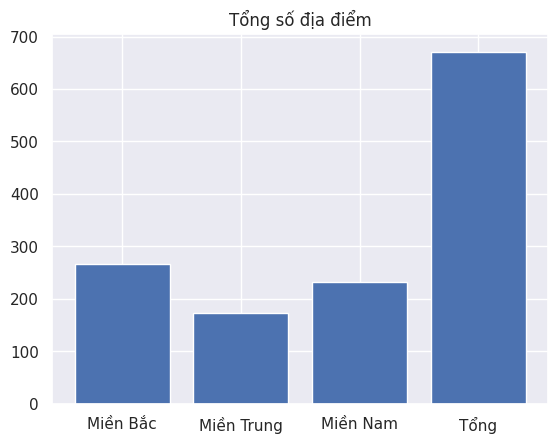

In [10]:
air_data_obj.location_analysis()

In [11]:
air_data_obj.load_aqi()

In [12]:
# air_data_obj.save()

In [13]:
air_data_obj.aqi_northVN_daily['aqi_daily'].unique()

array([ 83,  49, 141, 100,  44, 156,  65, 105, 103,  39,  37, 150, 102,
        48, 104,  60, 140,  95,  85, 148,  31, 111,  36,  35,  30,  29,
        70,  98,  32,  28,  92,  46,  61,  90, 108,  75,  50, 114,  80,
        34,  53,  38,  47,  45, 101, 118,  25,  26,  62,  74,  68,  33,
        58,  88,  42,  40,  52,  55,  41,  51,  43,  59,  57,  27,  24,
        54,  56,  22,  69,  64, 112,  78,  73,  66,  71, 181, 134,  82,
       135, 110, 137, 161, 190, 129, 166, 119, 123, 160, 117, 133, 106,
       116, 132, 120, 127, 174, 182, 136, 115, 130, 124,  72, 165, 109,
        76,  67, 188, 194, 185, 107, 121, 159, 131, 154, 186, 198, 122,
       113, 200, 126, 147, 151, 169, 178, 171, 155, 144,  97, 172, 128,
       125,  23,  20,  21,  18,  17, 146, 203, 214, 205, 195, 208, 206,
       145, 138, 192, 176, 164,  94,  81, 153, 225, 143, 168, 142, 223,
        91, 158, 201, 202, 149, 139, 204, 170, 152,  63, 179, 189, 162,
       184, 191,  86,  96,  79,  93,  99,  89,  84,  87, 207,  7

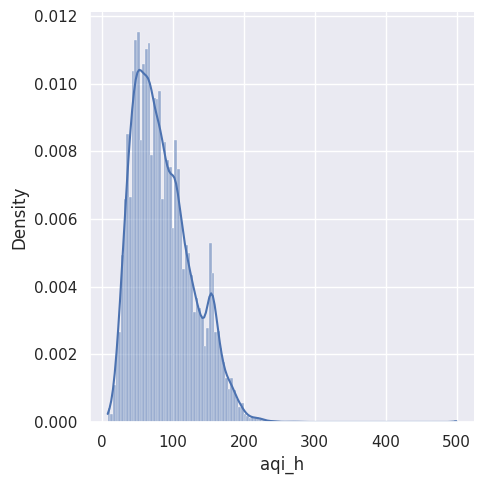

In [14]:
sns.displot(air_data_obj.northVN_dataAIR[air_data_obj.northVN_dataAIR['district']=='Ba Dinh'],x='aqi_h',stat='density',kde=True)

Số giá trị NaN

Số dữ liệu NaN Miền Bắc
Chỉ số: district Số giá trị thiếu: 0/8189424 Tỉ lệ: 0.00 % 
Chỉ số: city Số giá trị thiếu: 0/8189424 Tỉ lệ: 0.00 % 
Chỉ số: pm10 (μg/m³) Số giá trị thiếu: 1869/8189424 Tỉ lệ: 0.02 % 
Chỉ số: pm2_5 (μg/m³) Số giá trị thiếu: 1869/8189424 Tỉ lệ: 0.02 % 
Chỉ số: carbon_monoxide (μg/m³) Số giá trị thiếu: 1869/8189424 Tỉ lệ: 0.02 % 
Chỉ số: nitrogen_dioxide (μg/m³) Số giá trị thiếu: 1869/8189424 Tỉ lệ: 0.02 % 
Chỉ số: sulphur_dioxide (μg/m³) Số giá trị thiếu: 1869/8189424 Tỉ lệ: 0.02 % 
Chỉ số: ozone (μg/m³) Số giá trị thiếu: 1869/8189424 Tỉ lệ: 0.02 % 
Chỉ số: aerosol_optical_depth () Số giá trị thiếu: 1869/8189424 Tỉ lệ: 0.02 % 
Chỉ số: dust (μg/m³) Số giá trị thiếu: 1869/8189424 Tỉ lệ: 0.02 % 
Chỉ số: uv_index () Số giá trị thiếu: 1869/8189424 Tỉ lệ: 0.02 % 
Chỉ số: uv_index_clear_sky () Số giá trị thiếu: 1869/8189424 Tỉ lệ: 0.02 % 
Chỉ số: nowcast_pm10 Số giá trị thiếu: 1869/8189424 Tỉ lệ: 0.02 % 
Chỉ số: aqi_pm10 Số giá trị thiếu: 0/8189424 Tỉ lệ: 0.00 % 
Chỉ số:

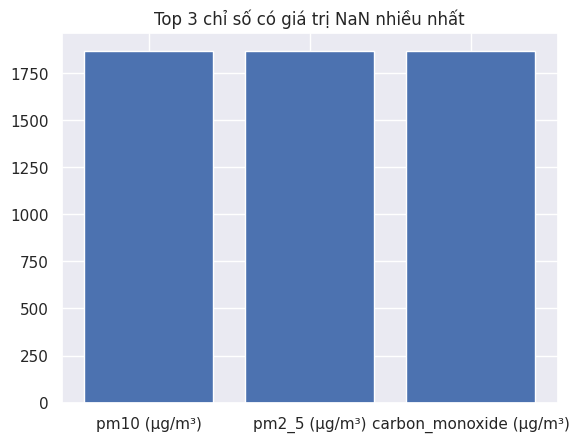

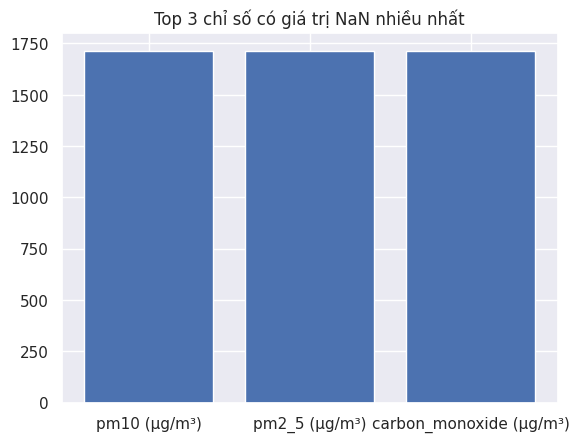

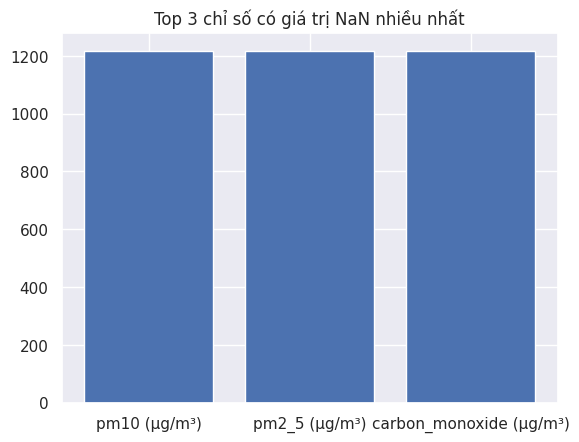

In [15]:
air_data_obj.check_nan()

In [16]:
air_data_obj.get_statistic_features()

Đặc trưng thống kê Miền Bắc:
Giá trị: pm10 (μg/m³), Trung bình: 41.49, Độ lệch chuẩn: 31.15
Giá trị: pm2_5 (μg/m³), Trung bình: 32.26, Độ lệch chuẩn: 24.98
Giá trị: carbon_monoxide (μg/m³), Trung bình: 464.57, Độ lệch chuẩn: 286.94
Giá trị: nitrogen_dioxide (μg/m³), Trung bình: 15.30, Độ lệch chuẩn: 16.14
Giá trị: sulphur_dioxide (μg/m³), Trung bình: 16.90, Độ lệch chuẩn: 14.56
Giá trị: ozone (μg/m³), Trung bình: 75.04, Độ lệch chuẩn: 42.79
Giá trị: aerosol_optical_depth (), Trung bình: 0.54, Độ lệch chuẩn: 0.41
Giá trị: dust (μg/m³), Trung bình: 0.58, Độ lệch chuẩn: 2.86
Giá trị: uv_index (), Trung bình: 1.24, Độ lệch chuẩn: 2.16
Giá trị: uv_index_clear_sky (), Trung bình: 1.97, Độ lệch chuẩn: 3.11
--------------------------------------------------
Đặc trưng thống kê Miền Nam:
Giá trị: pm10 (μg/m³), Trung bình: 23.26, Độ lệch chuẩn: 16.01
Giá trị: pm2_5 (μg/m³), Trung bình: 17.46, Độ lệch chuẩn: 13.84
Giá trị: carbon_monoxide (μg/m³), Trung bình: 294.68, Độ lệch chuẩn: 209.12
Giá trị:

Handle missing Value

In [17]:
air_data_obj.handle_missing_value()
    

Hanle missing value in Miền Bắc
Done !
--------------------------------------------------
Hanle missing value in Miền Nam
Done !
--------------------------------------------------
Hanle missing value in Miền Trung
Done !
--------------------------------------------------


Visualize Ha Noi AIR DATA

In [18]:
hanoi_data=air_data_obj.northVN_dataAIR[air_data_obj.northVN_dataAIR['city']=='Ha Noi'][['district','city','aqi_h']].copy()
hanoi_data_aqi=air_data_obj.aqi_northVN_daily[air_data_obj.aqi_northVN_daily['city']=='Ha Noi'][['district','city','aqi_daily']].copy()

In [19]:
print('AQI hourly')
print(hanoi_data['aqi_h'].describe())
print('AQI daily')
print(hanoi_data_aqi['aqi_daily'].describe())

AQI hourly
count    920160.000000
mean         88.399228
std          41.711892
min           6.000000
25%          56.000000
50%          82.000000
75%         115.000000
max         500.000000
Name: aqi_h, dtype: float64
AQI daily
count    38340.000000
mean       114.675117
std         48.041473
min         18.000000
25%         75.000000
50%        115.000000
75%        149.000000
max        270.000000
Name: aqi_daily, dtype: float64


Time Plot

AQI BA DINH

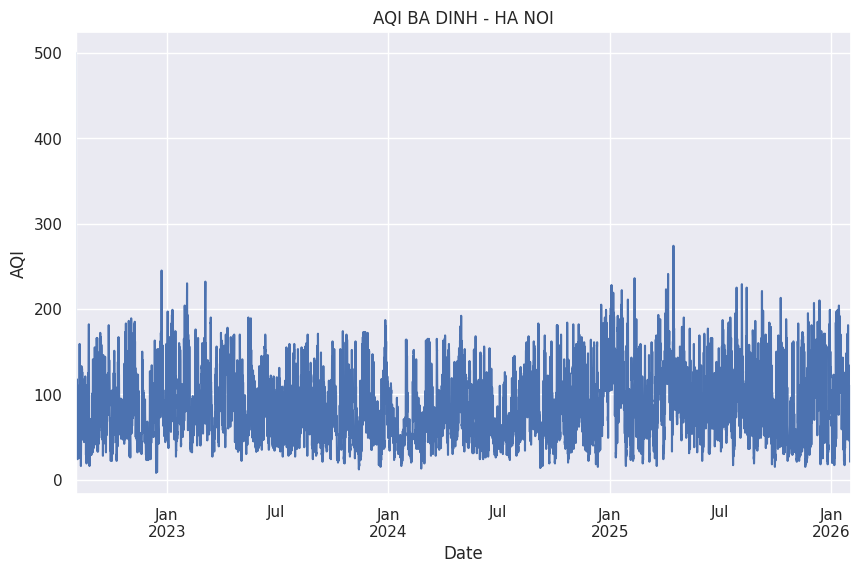

In [20]:
plt.figure(figsize=(10,6))
hanoi_data[hanoi_data['district']=='Ba Dinh']['aqi_h'].plot(title="AQI BA DINH - HA NOI")
plt.ylabel('AQI')
plt.xlabel('Date')
plt.show()

AQI HA DONG

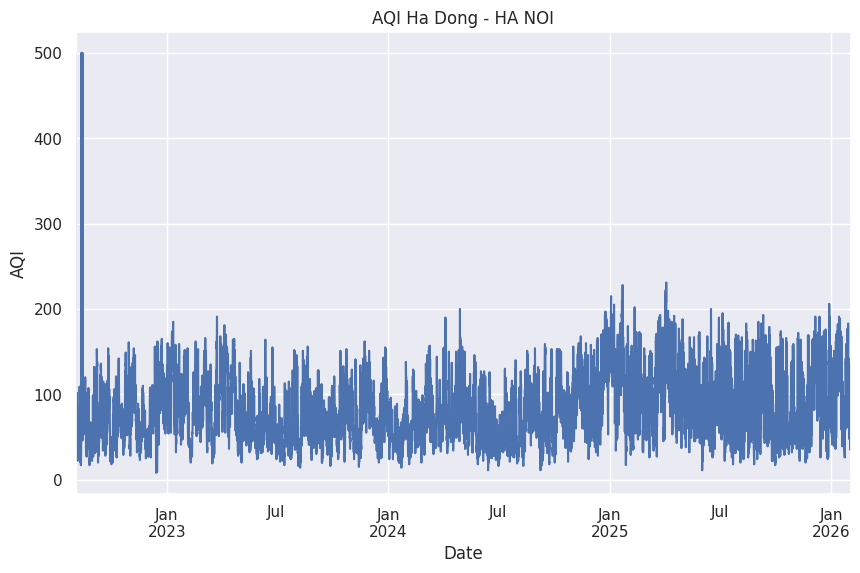

In [21]:
plt.figure(figsize=(10,6))
hanoi_data[hanoi_data['district']=='Ha Dong']['aqi_h'].plot(title="AQI Ha Dong - HA NOI")
plt.ylabel('AQI')
plt.xlabel('Date')
plt.show()

Nhận xét: Chất lượng aqi có xu hướng biến đổi theo từng năm. Mỗi năm có xu hướng biến đổi gần giống nhau

AQI DAILY BA DINH HA NOI

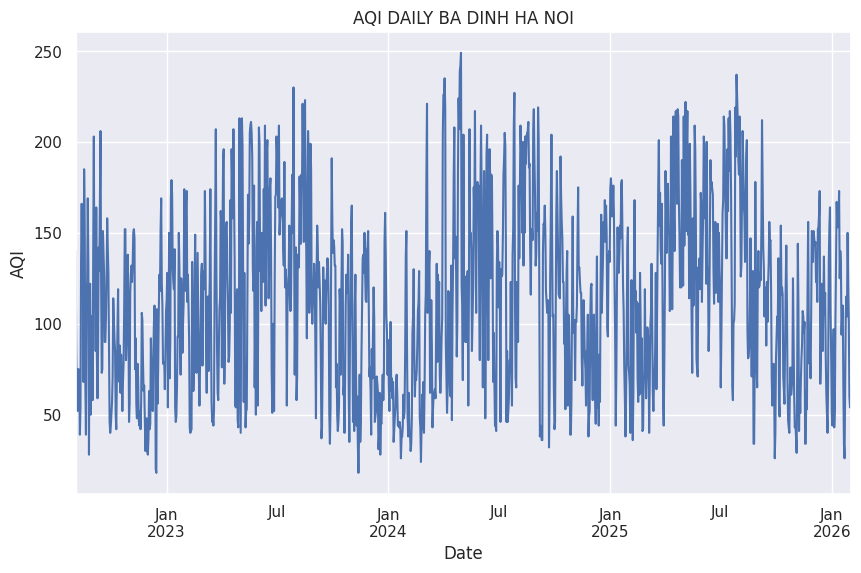

In [22]:
plt.figure(figsize=(10,6))
hanoi_data_aqi[hanoi_data_aqi['district']=='Ba Dinh']['aqi_daily'].plot(title='AQI DAILY BA DINH HA NOI')
plt.ylabel('AQI')
plt.xlabel('Date')
plt.show()

AQI HA DONG HA NOI

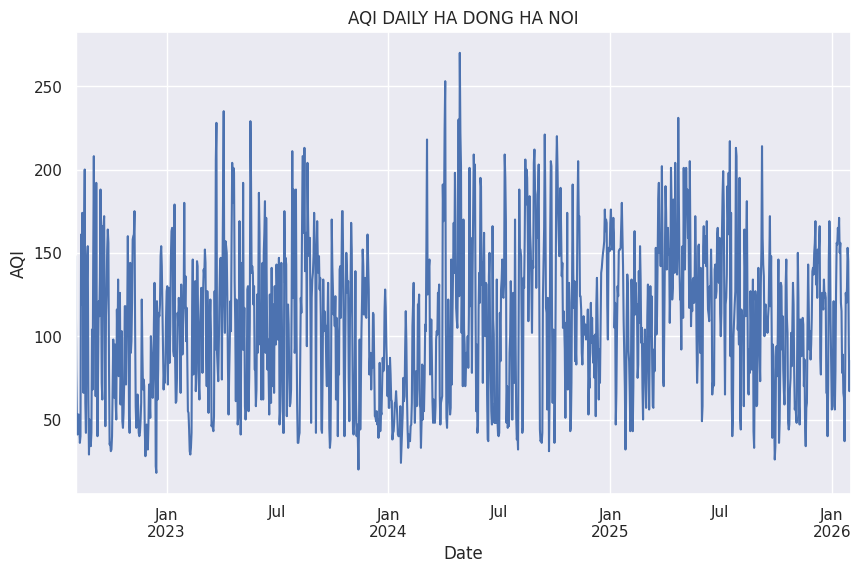

In [23]:
plt.figure(figsize=(10,6))
hanoi_data_aqi[hanoi_data_aqi['district']=='Ha Dong']['aqi_daily'].plot(title='AQI DAILY HA DONG HA NOI')
plt.ylabel('AQI')
plt.xlabel('Date')
plt.show()

Seasonal Plots

In [24]:
hanoi_data['year']=hanoi_data.index.year
hanoi_data_aqi['year']=hanoi_data_aqi.index.year
hanoi_data['month']=hanoi_data.index.month
hanoi_data_aqi['month']=hanoi_data_aqi.index.month
hanoi_data['week']=hanoi_data.index.isocalendar().week
hanoi_data_aqi['week']=hanoi_data_aqi.index.isocalendar().week
hanoi_data['hour']=hanoi_data.index.hour
hanoi_data_aqi['hour']=hanoi_data_aqi.index.hour
hanoi_data['day']=hanoi_data.index.dayofweek
hanoi_data_aqi['day']=hanoi_data_aqi.index.dayofweek
hanoi_data['day_str']=hanoi_data.index.strftime('%a')
hanoi_data_aqi['day_str']=hanoi_data_aqi.index.strftime('%a')
hanoi_data['year_month']=hanoi_data.index.strftime('%Y_%m')
hanoi_data_aqi['year_month']=hanoi_data_aqi.index.strftime('%Y_%m')

HA DONG AQI Yearly AQI

In [25]:
hd_data=hanoi_data[hanoi_data['district']=='Ha Dong'].copy()
hd_data_aqi=hanoi_data_aqi[hanoi_data_aqi['district']=='Ha Dong'].copy()

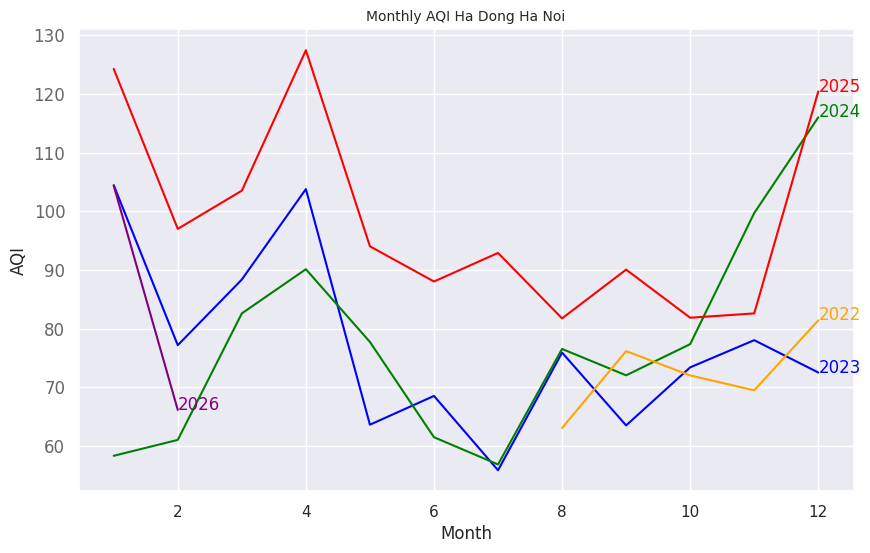

In [26]:
df_plot=hd_data[['month','year','aqi_h']].dropna().groupby(['month','year']).mean()[['aqi_h']].reset_index()
years=df_plot['year'].unique()
colors = ['blue', 'green', 'red', 'purple', 'orange']
plt.figure(figsize=(10,6))
for i,y in enumerate(years):
    if i<len(colors):
        plt.plot('month','aqi_h',data=df_plot[df_plot['year']==y],color=colors[i],label=y)
        plt.text(df_plot.loc[df_plot.year==y,'month'].iloc[-1],df_plot.loc[df_plot.year==y, 'aqi_h'][-1:].values[0], y, fontsize=12, color=colors[i])
plt.gca().set(ylabel='AQI',xlabel='Month')
plt.yticks(fontsize=12,alpha=.7)
plt.title('Monthly AQI Ha Dong Ha Noi',fontsize=10)
plt.ylabel('AQI')
plt.xlabel('Month')
plt.show()

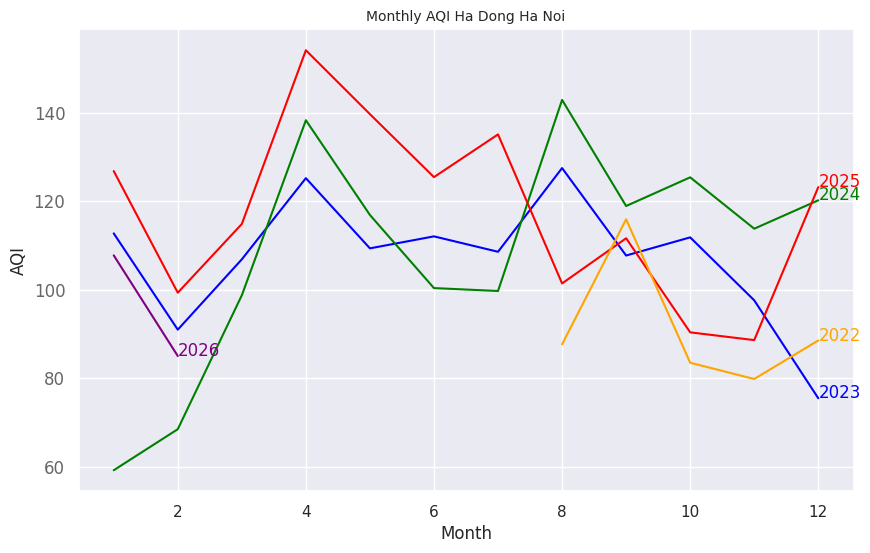

In [27]:
df_plot=hd_data_aqi[['month','year','aqi_daily']].dropna().groupby(['month','year']).mean()[['aqi_daily']].reset_index()
years=df_plot['year'].unique()
colors = ['blue', 'green', 'red', 'purple', 'orange']
plt.figure(figsize=(10,6))
for i,y in enumerate(years):
    if i<len(colors):
        plt.plot('month','aqi_daily',data=df_plot[df_plot['year']==y],color=colors[i],label=y)
        plt.text(df_plot.loc[df_plot.year==y,'month'].iloc[-1],df_plot.loc[df_plot.year==y, 'aqi_daily'][-1:].values[0], y, fontsize=12, color=colors[i])
plt.gca().set(ylabel='AQI',xlabel='Month')
plt.yticks(fontsize=12,alpha=.7)
plt.title('Monthly AQI Ha Dong Ha Noi',fontsize=10)
plt.ylabel('AQI')
plt.xlabel('Month')
plt.show()

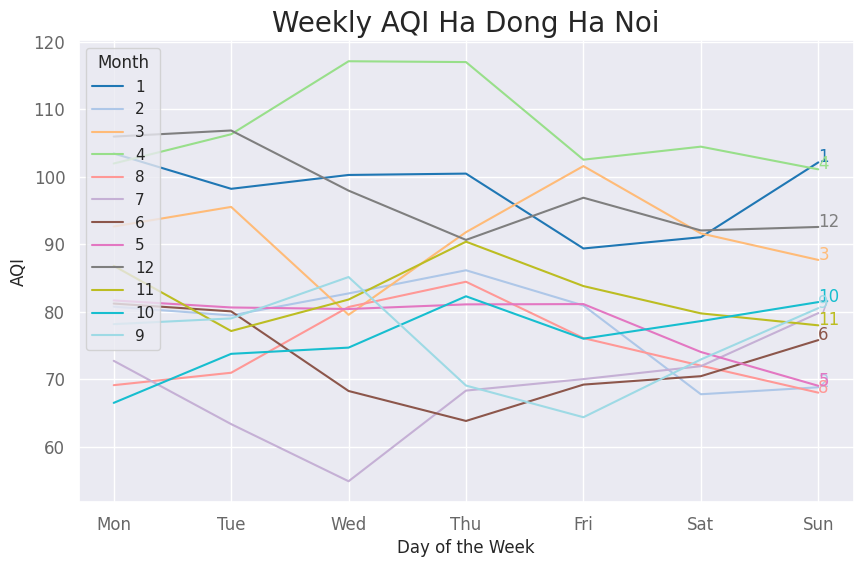

In [28]:
df_plot=hd_data[['month','day_str','aqi_h','day']].dropna()
df_plot=df_plot.groupby(['day_str','month','day']).mean()[['aqi_h']].reset_index()
df_plot=df_plot.sort_values(by='day',ascending=True)
months=df_plot['month'].unique()
colors=plt.get_cmap('tab20',len(months)).colors
plt.figure(figsize=(10,6))
for i,month in enumerate(months):
    month_data=df_plot[df_plot['month']==month]
    plt.plot(month_data['day_str'],month_data['aqi_h'],color=colors[i],label=month)
    plt.text(len(month_data['day_str'])-1,month_data['aqi_h'].iloc[-1],month,fontsize=12,color=colors[i])
plt.xlabel('Day of the Week')
plt.ylabel('AQI')
plt.title('Weekly AQI Ha Dong Ha Noi',fontsize=20)
plt.xticks(fontsize=12,alpha=0.7)
plt.yticks(fontsize=12,alpha=0.7)
plt.legend(title='Month',loc=2)
plt.show()

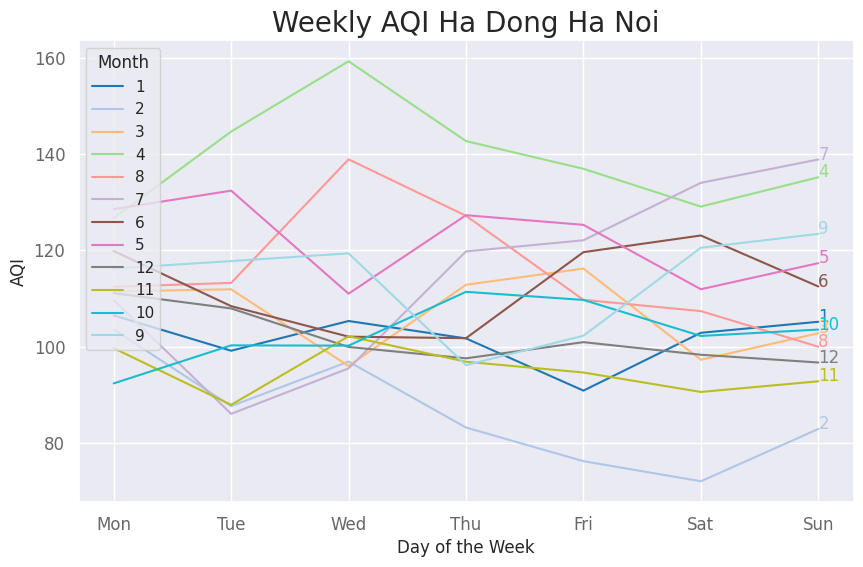

In [29]:
df_plot=hd_data_aqi[['month','day_str','aqi_daily','day']].dropna()
df_plot=df_plot.groupby(['day_str','month','day']).mean()[['aqi_daily']].reset_index()
df_plot=df_plot.sort_values(by='day',ascending=True)
months=df_plot['month'].unique()
colors=plt.get_cmap('tab20',len(months)).colors
plt.figure(figsize=(10,6))
for i,month in enumerate(months):
    month_data=df_plot[df_plot['month']==month]
    plt.plot(month_data['day_str'],month_data['aqi_daily'],color=colors[i],label=month)
    plt.text(len(month_data['day_str'])-1,month_data['aqi_daily'].iloc[-1],month,fontsize=12,color=colors[i])
plt.xlabel('Day of the Week')
plt.ylabel('AQI')
plt.title('Weekly AQI Ha Dong Ha Noi',fontsize=20)
plt.xticks(fontsize=12,alpha=0.7)
plt.yticks(fontsize=12,alpha=0.7)
plt.legend(title='Month',loc=2)
plt.show()

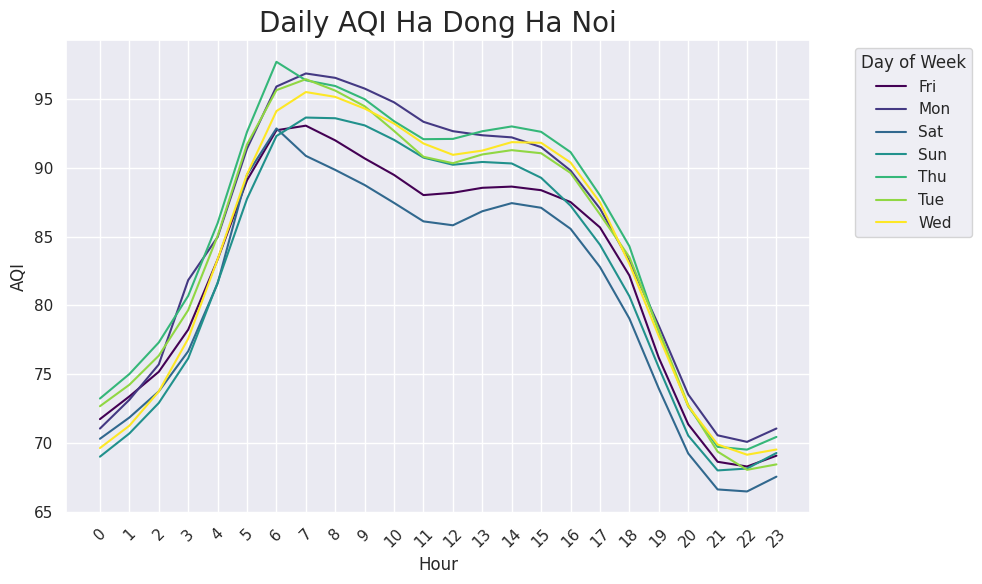

In [30]:
df_plot=hd_data[['hour','day_str','aqi_h']].dropna()
df_plot=df_plot.groupby(['hour','day_str']).mean().reset_index()
plt.figure(figsize=(10,6))
days=df_plot['day_str'].unique()
colors=plt.cm.viridis(np.linspace(0,1,len(days)))
for i,day in enumerate(days):
    day_data=df_plot[df_plot['day_str']==day]
    plt.plot(day_data['hour'],day_data['aqi_h'],label=day,color=colors[i])
plt.xticks(ticks=range(0, 24), labels=[str(i) for i in range(24)], rotation=45)
plt.title("Daily AQI Ha Dong Ha Noi", fontsize=20)
plt.ylabel('AQI')
plt.xlabel('Hour')
plt.legend(title='Day of Week', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [31]:
hd_data[['hour','day_str','aqi_h']].groupby(['hour','day_str']).mean().max()

aqi_h    97.710383
dtype: float64

Box Plots

Text(0.5, 1.0, 'Ha Dong Boxplot AQI hourly')

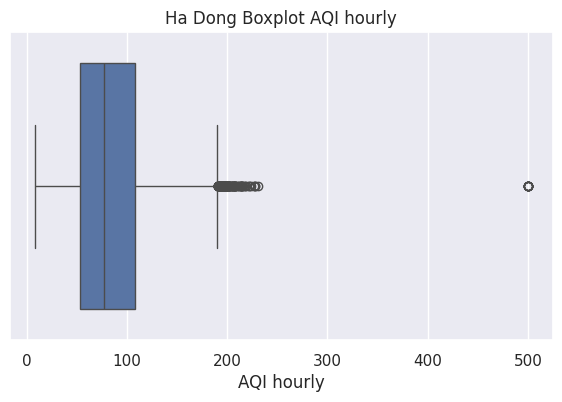

In [32]:
plt.figure(figsize=(7,4))
sns.boxplot(data=hd_data,x='aqi_h')
plt.xlabel('AQI hourly')
plt.title('Ha Dong Boxplot AQI hourly')

Text(0.5, 1.0, 'Ha Dong Boxplot AQI daily')

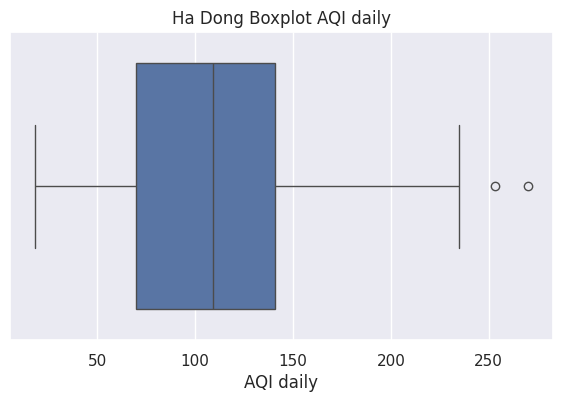

In [33]:
plt.figure(figsize=(7,4))
sns.boxplot(data=hd_data_aqi,x='aqi_daily')
plt.xlabel('AQI daily')
plt.title('Ha Dong Boxplot AQI daily')

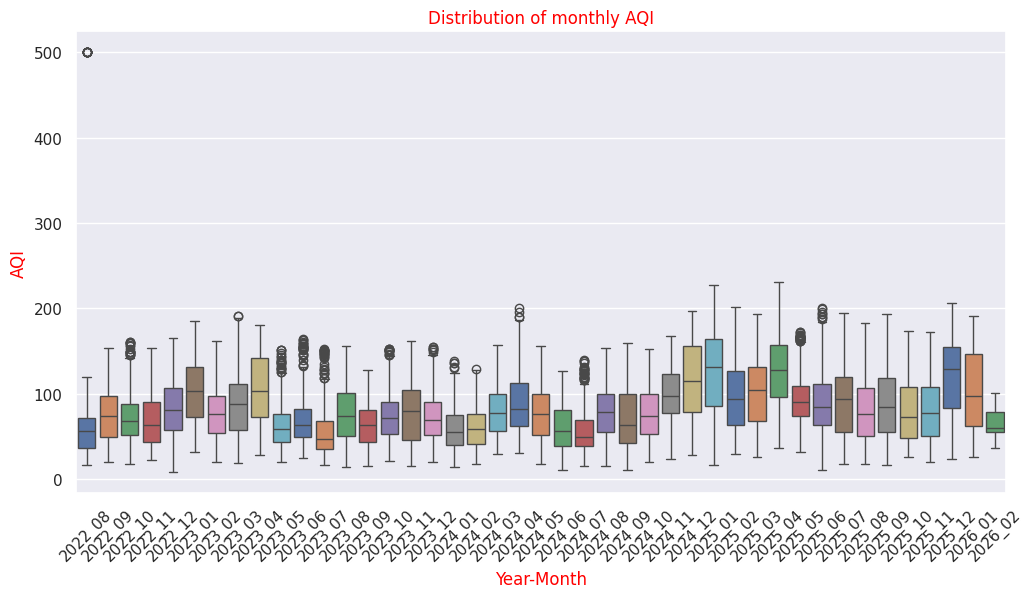

In [34]:
# Extracting year and month features
df_plot = hd_data
plt.figure(figsize=(12, 6))
sns.boxplot(x='year_month', y='aqi_h', data=df_plot,palette='deep',hue='year_month',legend=False)
plt.title('Distribution of monthly AQI', color='red')
plt.xlabel('Year-Month', color ='red')
plt.ylabel('AQI', color ='red')
plt.xticks(rotation=45)
plt.show()

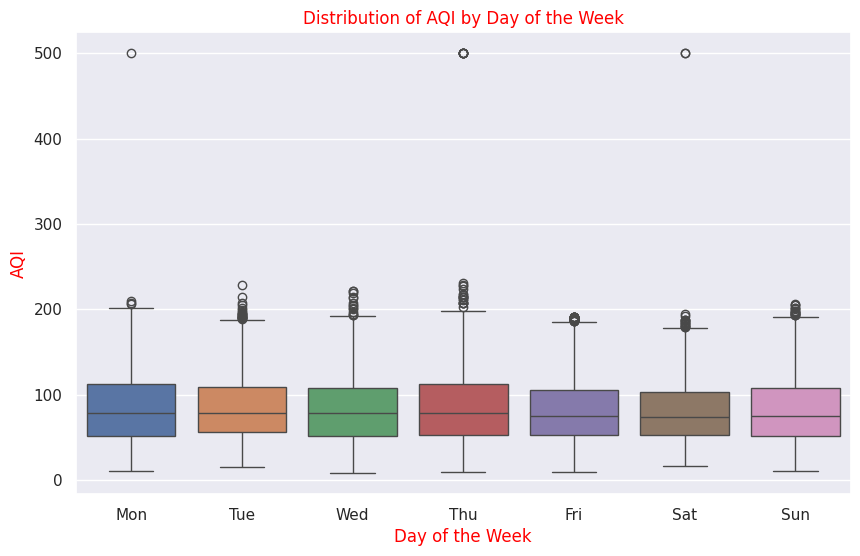

In [35]:
df_plot = hd_data[['day_str', 'day', 'aqi_h']].sort_values(by='day')
plt.figure(figsize=(10, 6))
sns.boxplot(x='day_str', y='aqi_h', data=df_plot,palette='deep',hue='day_str',legend=False)
plt.title('Distribution of AQI by Day of the Week', color ='red')
plt.xlabel('Day of the Week', color ='red')
plt.ylabel('AQI', color='red')
plt.show()

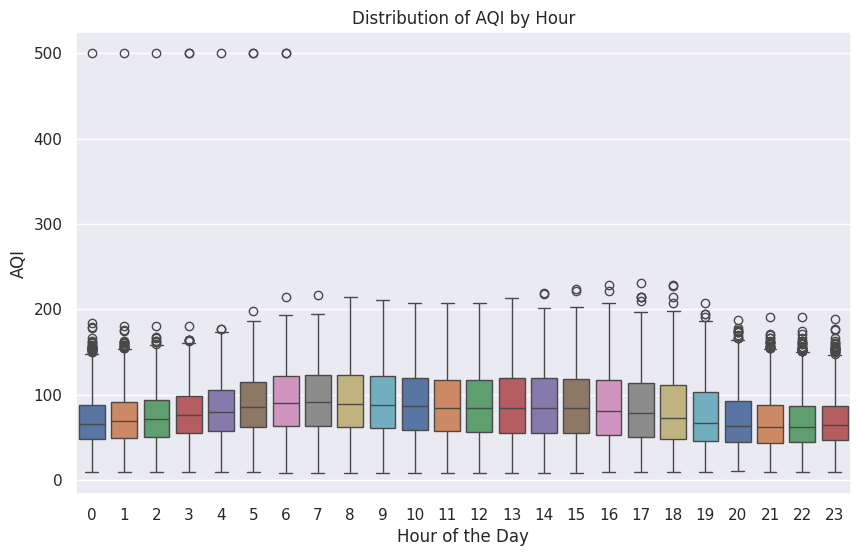

In [36]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=hd_data,x='hour', y='aqi_h',palette='deep',hue='hour',legend=False)
plt.title('Distribution of AQI by Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('AQI')
plt.show()

Normalize data

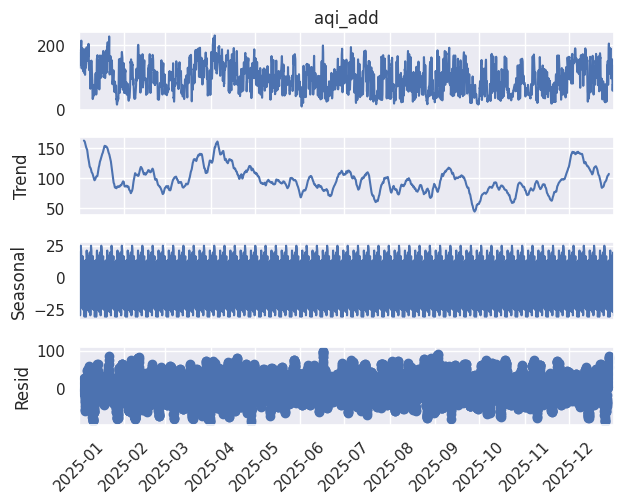

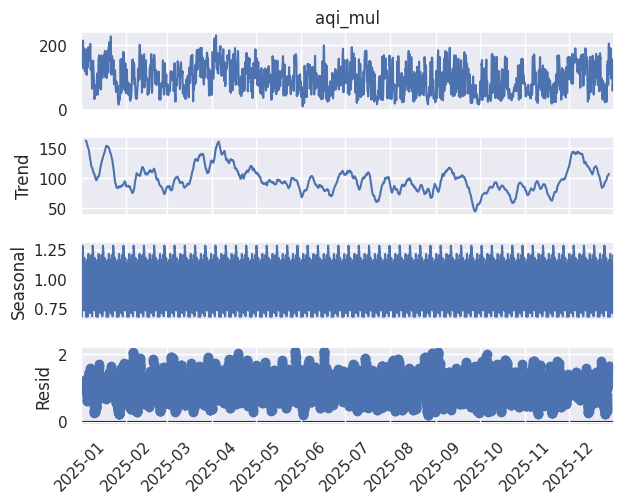

In [37]:
from statsmodels.tsa.seasonal import seasonal_decompose
df_plot=hd_data[hd_data['year']==2025].copy()
df_plot['aqi_mul']=df_plot['aqi_h']
df_plot['aqi_add']=df_plot['aqi_h']
result_add=seasonal_decompose(df_plot['aqi_add'],model='additive',period=24*7)
result_mul=seasonal_decompose(df_plot['aqi_mul'],model='multiplicative',period=24*7)
result_add.plot().suptitle('',fontsize=22)
plt.xticks(rotation=45)
result_mul.plot().suptitle('',fontsize=22)
plt.xticks(rotation=45)
plt.show()


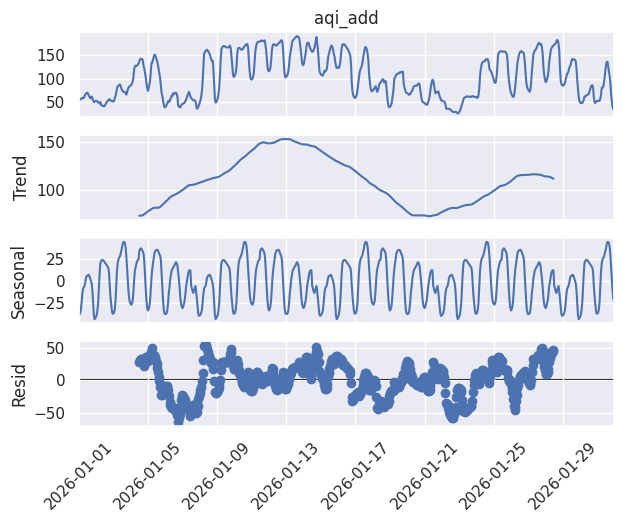

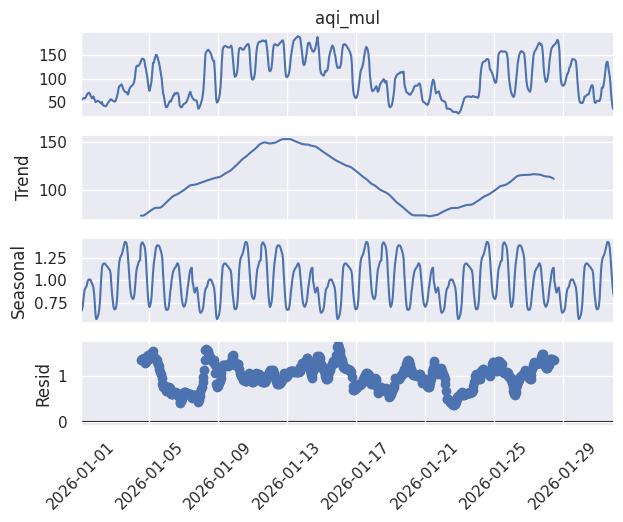

In [38]:
df_plot=hd_data[(hd_data['month']==1) & (hd_data['year']==2026)].copy()
df_plot['aqi_mul']=df_plot['aqi_h']
df_plot['aqi_add']=df_plot['aqi_h']
result_add=seasonal_decompose(df_plot['aqi_add'],model='additive',period=24*7)
result_mul=seasonal_decompose(df_plot['aqi_mul'],model='multiplicative',period=24*7)
result_add.plot().suptitle('',fontsize=22)
plt.xticks(rotation=45)
result_mul.plot().suptitle('',fontsize=22)
plt.xticks(rotation=45)
plt.show()

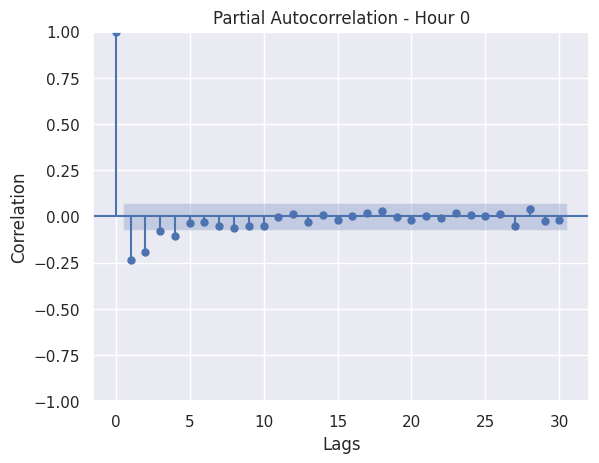

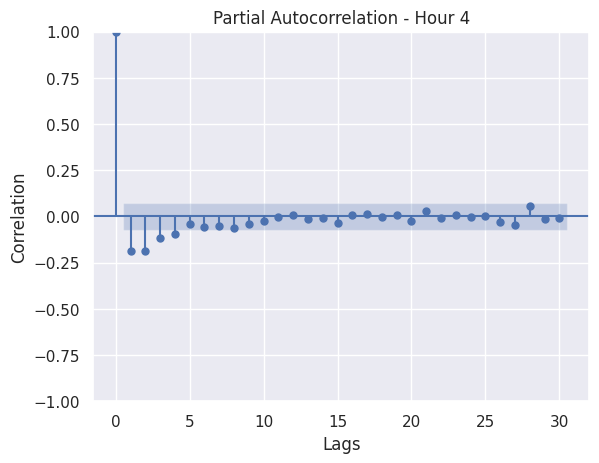

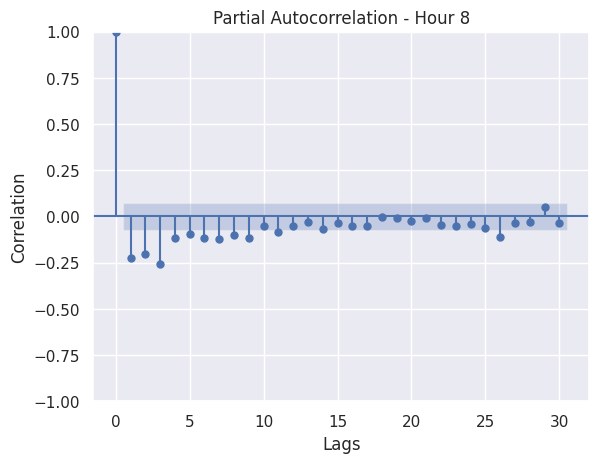

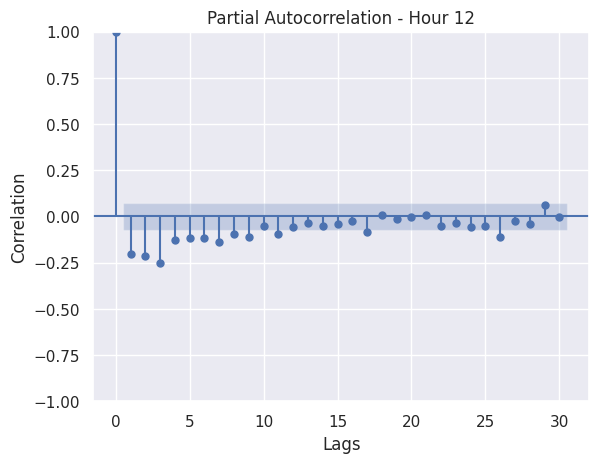

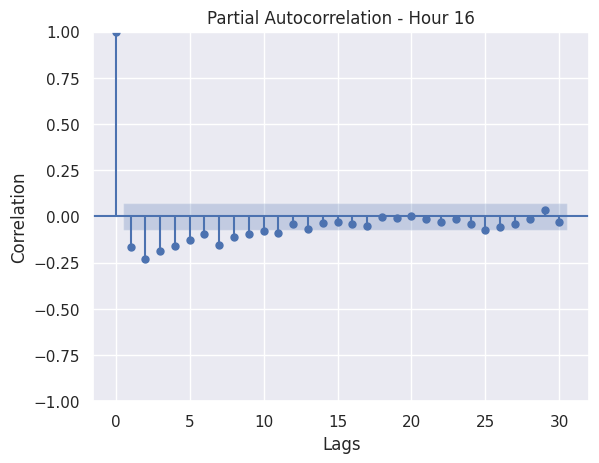

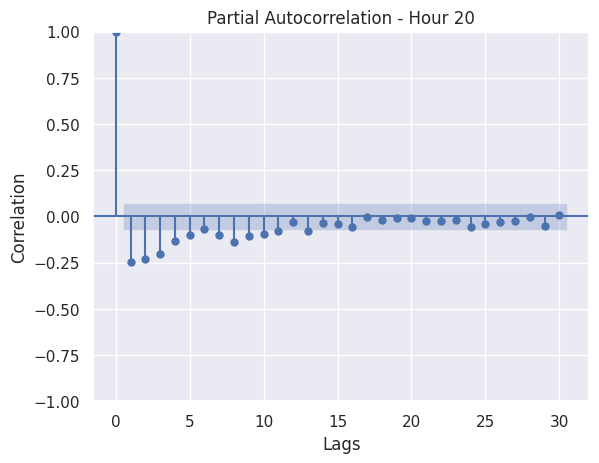

In [39]:
from statsmodels.graphics.tsaplots import plot_pacf

actual = hd_data['aqi_h']
hours_of_interest = range(0, 24, 4)

for hour in hours_of_interest:
    hour_data = actual[actual.index.hour == hour].diff().dropna()
    plot_pacf(hour_data, lags=30, alpha=0.01)
    plt.title(f'Partial Autocorrelation - Hour {hour}')
    plt.ylabel('Correlation')
    plt.xlabel('Lags')
    plt.show()

Weather Data

In [40]:
class WeatherData:
    def __init__(self,data_path):
        self.data_path=data_path
        self.northVN_weatherAIR=self.read_csv_chunk('northVN_dataThoiTiet.csv')
        self.centralVN_weatherAIR=self.read_csv_chunk('centralVN_dataWeather.csv')
        self.southVN_weatherAIR=self.read_csv_chunk('southVN_dataWeather.csv')
        self.numerical_columns=['temperature_2m (°C)',
       'relative_humidity_2m (%)', 'apparent_temperature (°C)',
       'precipitation (mm)', 'rain (mm)', 'cloud_cover (%)',
       'cloud_cover_low (%)', 'cloud_cover_mid (%)', 'cloud_cover_high (%)',
       'wind_speed_10m (km/h)', 'wind_speed_100m (km/h)',
       'wind_direction_10m (°)', 'soil_temperature_0_to_7cm (°C)',
       'soil_temperature_7_to_28cm (°C)', 'soil_temperature_28_to_100cm (°C)',
       'soil_temperature_100_to_255cm (°C)', 'soil_moisture_0_to_7cm (m³/m³)',
       'soil_moisture_7_to_28cm (m³/m³)', 'soil_moisture_28_to_100cm (m³/m³)',
       'soil_moisture_100_to_255cm (m³/m³)']
        self.names=["Miền Bắc","Miền Nam",'Miền Trung']
        self.dfs=[self.northVN_weatherAIR,self.southVN_weatherAIR,self.centralVN_weatherAIR]
        print('load air data sucessfully!')
    def read_csv_chunk(self,path):
        chunk_size=10**6
        chunks=[]
        for chunk in pd.read_csv(os.path.join(self.data_path,path), parse_dates=['time'], index_col='time',chunksize=chunk_size):
            chunks.append(chunk)
        return pd.concat(chunks)
    def location_analysis(self):
        #Tong so dia diem mien bac
        n_locations=len(self.northVN_weatherAIR['district'].unique())
        #Tong so dia diem mien Nam
        s_locations=len(self.southVN_weatherAIR['district'].unique())
        #Tong so dia diem mien Trung
        c_locations=len(self.centralVN_weatherAIR['district'].unique())
        #Tong so dia diem tren Viet Nam
        total_locations=n_locations+s_locations+c_locations
        print("Tổng số địa điểm miền Bắc: {} địa điểm.".format(n_locations))
        print("Tổng số địa điểm miền Nam: {} địa điểm.".format(s_locations))
        print("Tổng số địa điểm miền Trung: {} địa điểm.".format(c_locations))
        print("Tổng số địa điểm trên Việt Nam: {} địa điểm.".format(total_locations))
        fig,ax=plt.subplots()
        ax.bar(["Miền Bắc","Miền Trung","Miền Nam","Tổng"],[n_locations,c_locations,s_locations,total_locations])
        ax.set_title('Tổng số địa điểm')
    def check_nan(self):
        for name,df in zip(self.names,self.dfs):
            dt={}
            print(f"Số dữ liệu NaN {name}")
            for column in df.columns:
                total_nan=df[column].isna().sum()
                dt[column]=int(total_nan)
                print('Chỉ số: {} Số giá trị thiếu: {}/{} Tỉ lệ: {:.2f} % '.format(column,total_nan,df.shape[0],total_nan*100/df.shape[0]))
            fix,ax=plt.subplots()
            dt={k: v for k, v in sorted(dt.items(), key=lambda item: item[1],reverse=True)}
            ax.bar(list(dt.keys())[:3],list(dt.values())[:3])
            ax.set_title("Top 3 chỉ số có giá trị NaN nhiều nhất")
            print('-'*50)
    def get_statistic_features(self):
        for name,df in zip(self.names,self.dfs):
            print("Đặc trưng thống kê {}:".format(name))
            for column in self.numerical_columns:
                mean=df[column].mean()
                std=np.std(df[column])
                print("Giá trị: {}, Trung bình: {:.2f}, Độ lệch chuẩn: {:.2f}".format(column,mean,std))
            print('-'*50)
    def handle_missing_value(self,drop=False):
        for name,df in zip(self.names,self.dfs):
            print("Hanle missing value in {}".format(name))
            for column in self.numerical_columns:
                if drop:
                    df[column].dropna()
                else:
                    mean=df[column].mean()
                    df[column]=df[column].fillna(mean)
            print('Done !')
            print('-'*50)

In [41]:
weather_data_obj=WeatherData('/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset')

load air data sucessfully!


In [42]:
weather_data_obj.southVN_weatherAIR.shape

(21667800, 22)

Tổng số địa điểm miền Bắc: 266 địa điểm.
Tổng số địa điểm miền Nam: 231 địa điểm.
Tổng số địa điểm miền Trung: 173 địa điểm.
Tổng số địa điểm trên Việt Nam: 670 địa điểm.


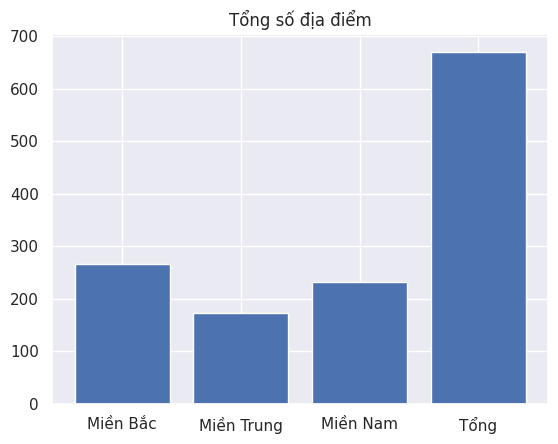

In [43]:
weather_data_obj.location_analysis()

Số dữ liệu NaN Miền Bắc
Chỉ số: district Số giá trị thiếu: 0/23613480 Tỉ lệ: 0.00 % 
Chỉ số: city Số giá trị thiếu: 0/23613480 Tỉ lệ: 0.00 % 
Chỉ số: temperature_2m (°C) Số giá trị thiếu: 0/23613480 Tỉ lệ: 0.00 % 
Chỉ số: relative_humidity_2m (%) Số giá trị thiếu: 0/23613480 Tỉ lệ: 0.00 % 
Chỉ số: apparent_temperature (°C) Số giá trị thiếu: 0/23613480 Tỉ lệ: 0.00 % 
Chỉ số: precipitation (mm) Số giá trị thiếu: 0/23613480 Tỉ lệ: 0.00 % 
Chỉ số: rain (mm) Số giá trị thiếu: 0/23613480 Tỉ lệ: 0.00 % 
Chỉ số: cloud_cover (%) Số giá trị thiếu: 0/23613480 Tỉ lệ: 0.00 % 
Chỉ số: cloud_cover_low (%) Số giá trị thiếu: 0/23613480 Tỉ lệ: 0.00 % 
Chỉ số: cloud_cover_mid (%) Số giá trị thiếu: 0/23613480 Tỉ lệ: 0.00 % 
Chỉ số: cloud_cover_high (%) Số giá trị thiếu: 0/23613480 Tỉ lệ: 0.00 % 
Chỉ số: wind_speed_10m (km/h) Số giá trị thiếu: 0/23613480 Tỉ lệ: 0.00 % 
Chỉ số: wind_speed_100m (km/h) Số giá trị thiếu: 0/23613480 Tỉ lệ: 0.00 % 
Chỉ số: wind_direction_10m (°) Số giá trị thiếu: 0/23613480 Tỉ l

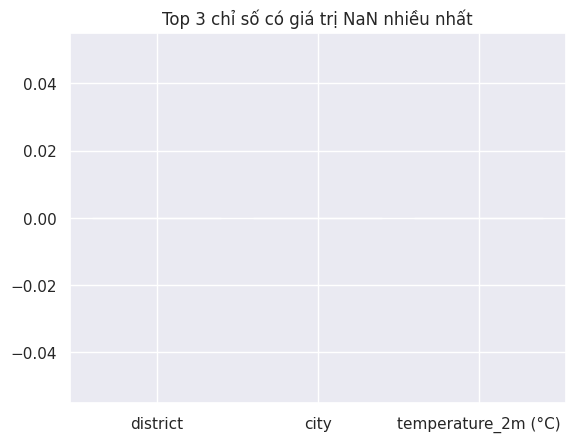

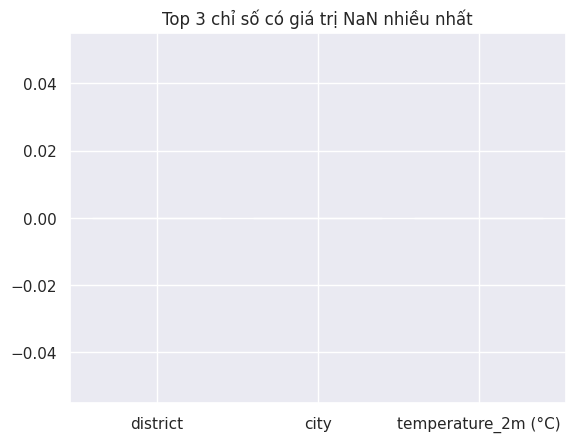

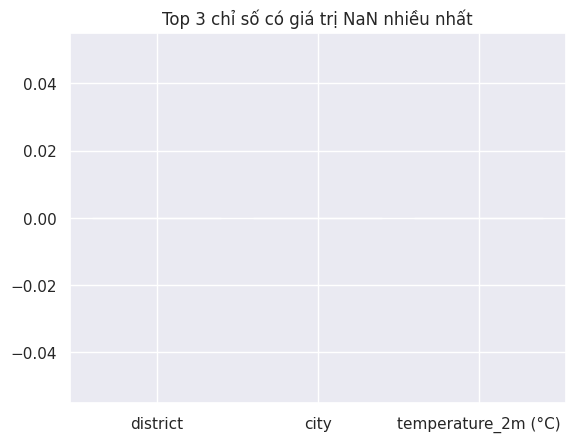

In [44]:
weather_data_obj.check_nan()

In [45]:
weather_data_obj.get_statistic_features()

Đặc trưng thống kê Miền Bắc:
Giá trị: temperature_2m (°C), Trung bình: 22.88, Độ lệch chuẩn: 5.78
Giá trị: relative_humidity_2m (%), Trung bình: 81.52, Độ lệch chuẩn: 14.12
Giá trị: apparent_temperature (°C), Trung bình: 25.80, Độ lệch chuẩn: 8.28
Giá trị: precipitation (mm), Trung bình: 0.25, Độ lệch chuẩn: 0.97
Giá trị: rain (mm), Trung bình: 0.25, Độ lệch chuẩn: 0.97
Giá trị: cloud_cover (%), Trung bình: 72.52, Độ lệch chuẩn: 36.09
Giá trị: cloud_cover_low (%), Trung bình: 41.88, Độ lệch chuẩn: 41.78
Giá trị: cloud_cover_mid (%), Trung bình: 25.85, Độ lệch chuẩn: 32.85
Giá trị: cloud_cover_high (%), Trung bình: 41.92, Độ lệch chuẩn: 43.17
Giá trị: wind_speed_10m (km/h), Trung bình: 7.79, Độ lệch chuẩn: 5.00
Giá trị: wind_speed_100m (km/h), Trung bình: 12.84, Độ lệch chuẩn: 7.76
Giá trị: wind_direction_10m (°), Trung bình: 150.50, Độ lệch chuẩn: 97.68
Giá trị: soil_temperature_0_to_7cm (°C), Trung bình: 23.69, Độ lệch chuẩn: 5.37
Giá trị: soil_temperature_7_to_28cm (°C), Trung bình: 